# Universal Adversarial Perturbation (UAP) 白盒对抗攻击实验

本 notebook 在 CIFAR-10 上训练 **SimpleCNN**，然后使用 **Universal Adversarial Perturbation (UAP)** 方法生成一个**单一的、与图像无关的扰动向量 $v$**，使得把同一个 $v$ 加到大多数测试图像上都能让模型误分类。


## 1. UAP 攻击原理

**Universal Adversarial Perturbation（通用对抗扰动）** 由 Moosavi-Dezfooli 等人提出。与 FGSM、PGD、DeepFool 等**逐样本**攻击不同，UAP 的目标是找到 **一个固定的扰动向量 $v$**，满足 $\|v\|_p \le \xi$，并且对于数据分布中的**大多数样本 $x$** 都有：
$$\hat{k}(x + v) \neq \hat{k}(x)$$
其中 $\hat{k}(\cdot)$ 表示模型预测的标签。

UAP 是一种 **功能性攻击（functional attack）**：同一份噪声可以欺骗大量不同样本，对实际部署系统构成严重威胁。

> 参考：CAISP《模块二 技术基础篇》pp.120-121。


### UAP 算法流程

1. 初始化通用扰动 $v = 0$。
2. 在训练子集上循环：
   - 对每张图片 $x_i$，若 $\hat{k}(x_i + v) = \hat{k}(x_i)$（尚未被欺骗）：
     - 使用 DeepFool 风格方法计算最小扰动 $\delta_i$，使 $x_i + v + \delta_i$ 被误分类。
     - 更新 $v \leftarrow v + \delta_i$。
3. 将 $v$ 投影到 $L_2$ 球上：若 $\|v\|_2 > \xi$，则 $v \leftarrow \xi \cdot v / \|v\|_2$。
4. 计算当前 $v$ 在整个数据集的 **fooling rate**，若达到目标或达到最大迭代次数则停止。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# SimpleCNN 定义（与 FGSM/PGD/C&W 一致）
# ==============================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def train_model(model, train_loader, epochs=15, lr=1e-3):
    """训练 SimpleCNN。"""
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        acc = 100.0 * correct / total
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Train Acc: {acc:.2f}%")
    return model


In [2]:
# ==============================
# CIFAR-10 数据加载
# 使用训练集的一个子集（如 500 张）来生成 UAP
# ==============================
transform = transforms.ToTensor()
train_dataset = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)

# 选取前 500 张训练图像用于生成通用扰动
uap_train_size = 500
indices = list(range(uap_train_size))
uap_train_subset = Subset(train_dataset, indices)
uap_train_loader = DataLoader(uap_train_subset, batch_size=1, shuffle=True, num_workers=0)

# 完整训练集和测试集用于评估
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# ==============================
# 训练模型
# ==============================
model = SimpleCNN().to(device)
model = train_model(model, train_loader, epochs=15, lr=1e-3)
model.eval()
print("Training complete.")


Epoch 1/15, Loss: 1.5905, Train Acc: 42.54%
Epoch 2/15, Loss: 1.2702, Train Acc: 54.85%
Epoch 3/15, Loss: 1.1351, Train Acc: 59.94%
Epoch 4/15, Loss: 1.0339, Train Acc: 63.60%
Epoch 5/15, Loss: 0.9606, Train Acc: 66.47%
Epoch 6/15, Loss: 0.9036, Train Acc: 68.40%
Epoch 7/15, Loss: 0.8517, Train Acc: 70.23%
Epoch 8/15, Loss: 0.8090, Train Acc: 71.98%
Epoch 9/15, Loss: 0.7759, Train Acc: 72.83%
Epoch 10/15, Loss: 0.7327, Train Acc: 74.53%
Epoch 11/15, Loss: 0.7016, Train Acc: 75.32%
Epoch 12/15, Loss: 0.6722, Train Acc: 76.45%
Epoch 13/15, Loss: 0.6415, Train Acc: 77.41%
Epoch 14/15, Loss: 0.6094, Train Acc: 78.59%
Epoch 15/15, Loss: 0.5836, Train Acc: 79.41%
Training complete.


In [3]:
# ==============================
# DeepFool 辅助函数（用于 UAP 内部）
# 返回使 x 被误分类的最小 L2 扰动
# ==============================
def deepfool_perturbation(model, x, y, max_iter=30, overshoot=0.02):
    """
    计算让模型在 x 上发生误分类的最小 DeepFool 风格扰动。

    Args:
        model: 目标模型
        x: 输入样本 (1, C, H, W)，值域 [0,1]
        y: 当前预测标签（作为"正确"标签），形状 (1,)
        max_iter: 最大迭代次数
        overshoot: 边界超调量
    Returns:
        perturbation: 扰动向量 (C, H, W)
    """
    model.eval()
    x_orig = x.clone().detach()
    x_adv = x_orig.clone().detach().requires_grad_(True)
    label = y.item()
    num_classes = model(x_adv).shape[1]

    for it in range(max_iter):
        output = model(x_adv)
        pred = output.argmax(dim=1).item()
        if pred != label:
            break

        grads = []
        for k in range(num_classes):
            if x_adv.grad is not None:
                x_adv.grad.zero_()
            retain = (k < num_classes - 1)
            output[0, k].backward(retain_graph=retain)
            grads.append(x_adv.grad.clone())
        if x_adv.grad is not None:
            x_adv.grad.zero_()
        grads = torch.stack(grads, dim=0)

        scores = output.detach().squeeze(0)
        w_correct = grads[label]
        f_correct = scores[label].item()

        min_dist = float('inf')
        best_r = None
        for k in range(num_classes):
            if k == label:
                continue
            w_k = grads[k]
            f_k = scores[k].item()
            w_diff = w_k - w_correct
            norm_sq = torch.sum(w_diff * w_diff).item()
            if norm_sq < 1e-12:
                continue
            dist = abs(f_k - f_correct) / (norm_sq ** 0.5)
            r = (f_correct - f_k) / norm_sq * w_diff
            if dist < min_dist:
                min_dist = dist
                best_r = r

        if best_r is None:
            break

        x_adv = x_adv.detach() + (1 + overshoot) * best_r
        x_adv = torch.clamp(x_adv, 0, 1).requires_grad_(True)

    return (x_adv.detach() - x_orig).squeeze(0)


In [4]:
# ==============================
# 计算 fooling rate 的辅助函数
# ==============================
def compute_fooling_rate(model, data_loader, v):
    """
    计算通用扰动 v 在给定数据集上的 fooling rate。
    fooling_rate = 被欺骗的样本数 / 总样本数
    """
    model.eval()
    fooled = 0
    total = 0
    with torch.no_grad():
        for images, _ in data_loader:
            images = images.to(device)
            for i in range(images.shape[0]):
                x = images[i:i+1]
                pred_orig = model(x).argmax(dim=1).item()
                x_pert = torch.clamp(x + v, 0, 1)
                pred_pert = model(x_pert).argmax(dim=1).item()
                if pred_pert != pred_orig:
                    fooled += 1
                total += 1
    return fooled / total if total > 0 else 0.0


# ==============================
# 通用对抗扰动生成算法
# ==============================
def generate_uap(model, data_loader, xi=10.0, max_passes=10,
                 target_fooling_rate=0.8, max_iter_deepfool=30):
    """
    生成通用对抗扰动向量 v。

    Args:
        model: 目标模型
        data_loader: 用于生成 v 的数据加载器（batch_size=1）
        xi: L2 扰动上限
        max_passes: 最大遍历数据集轮数
        target_fooling_rate: 目标 fooling rate
        max_iter_deepfool: DeepFool 内部最大迭代次数
    Returns:
        v: 通用扰动向量 (C, H, W)
        fooling_rates: 每轮 fooling rate 列表
        norms: 每轮 ||v||_2 列表
    """
    v = torch.zeros((3, 32, 32), device=device)
    fooling_rates = []
    norms = []

    for t in range(max_passes):
        for images, _ in data_loader:
            images = images.to(device)
            x = images[0:1]

            # 当前模型对 x+v 的预测
            with torch.no_grad():
                pred_orig = model(x).argmax(dim=1).item()
                x_pert = torch.clamp(x + v, 0, 1)
                pred_pert = model(x_pert).argmax(dim=1).item()

            # 如果 x+v 已经被欺骗，则跳过
            if pred_pert != pred_orig:
                continue

            # 否则使用 DeepFool 计算能欺骗 x+v 的最小扰动
            delta = deepfool_perturbation(model, x_pert,
                                          torch.tensor([pred_pert], device=device),
                                          max_iter=max_iter_deepfool,
                                          overshoot=0.02)
            v = v + delta

            # 投影到 L2 球：||v||_2 <= xi
            norm_v = torch.norm(v, p=2)
            if norm_v > xi:
                v = xi * v / norm_v

        # 每轮结束后计算 fooling rate
        fr = compute_fooling_rate(model, data_loader, v)
        fooling_rates.append(fr)
        norms.append(torch.norm(v, p=2).item())
        print(f"Pass {t+1}/{max_passes}: fooling rate={fr:.4f}, ||v||_2={norms[-1]:.4f}")

        if fr >= target_fooling_rate:
            print(f"Reached target fooling rate {target_fooling_rate:.2f}, stopping early.")
            break

    return v, fooling_rates, norms


In [5]:
# ==============================
# 生成通用对抗扰动
# 参数说明：
#   xi: L2 范数上限，值越大扰动越明显、欺骗率通常越高
#   max_passes: 遍历子集的最大轮数
#   target_fooling_rate: 目标 fooling rate
# ==============================
xi = 10.0
v, fooling_rates, norms = generate_uap(
    model, uap_train_loader, xi=xi, max_passes=10,
    target_fooling_rate=0.8, max_iter_deepfool=30
)


Pass 1/10: fooling rate=0.7420, ||v||_2=4.5009
Pass 2/10: fooling rate=0.7900, ||v||_2=4.8585
Pass 3/10: fooling rate=0.8300, ||v||_2=4.9898
Reached target fooling rate 0.80, stopping early.


In [6]:
# ==============================
# 评估 UAP 在训练子集和测试集上的表现
# ==============================
train_fr = compute_fooling_rate(model, uap_train_loader, v)
test_fr = compute_fooling_rate(model, test_loader, v)

print(f"===== Universal Adversarial Perturbation Evaluation =====")
print(f"L2 bound xi = {xi}")
print(f"Training subset fooling rate: {100.0 * train_fr:.2f}%")
print(f"Test set fooling rate: {100.0 * test_fr:.2f}%")
print(f"Final ||v||_2: {torch.norm(v, p=2).item():.4f}")


===== Universal Adversarial Perturbation Evaluation =====
L2 bound xi = 10.0
Training subset fooling rate: 83.00%
Test set fooling rate: 74.86%
Final ||v||_2: 4.9898


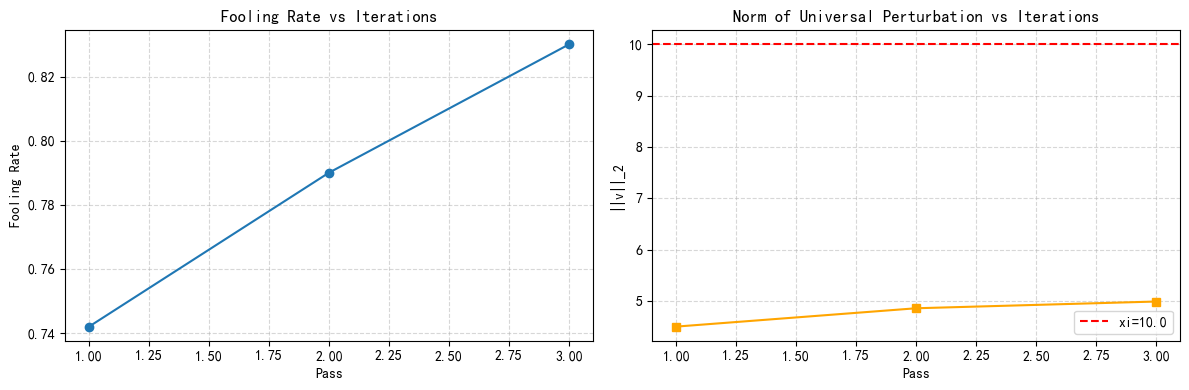

In [7]:
# ==============================
# 可视化：fooling rate 与 ||v||_2 随轮次变化
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(fooling_rates) + 1), fooling_rates, marker='o')
axes[0].set_xlabel("Pass")
axes[0].set_ylabel("Fooling Rate")
axes[0].set_title("Fooling Rate vs Iterations")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(range(1, len(norms) + 1), norms, marker='s', color='orange')
axes[1].axhline(y=xi, color='r', linestyle='--', label=f"xi={xi}")
axes[1].set_xlabel("Pass")
axes[1].set_ylabel("||v||_2")
axes[1].set_title("Norm of Universal Perturbation vs Iterations")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


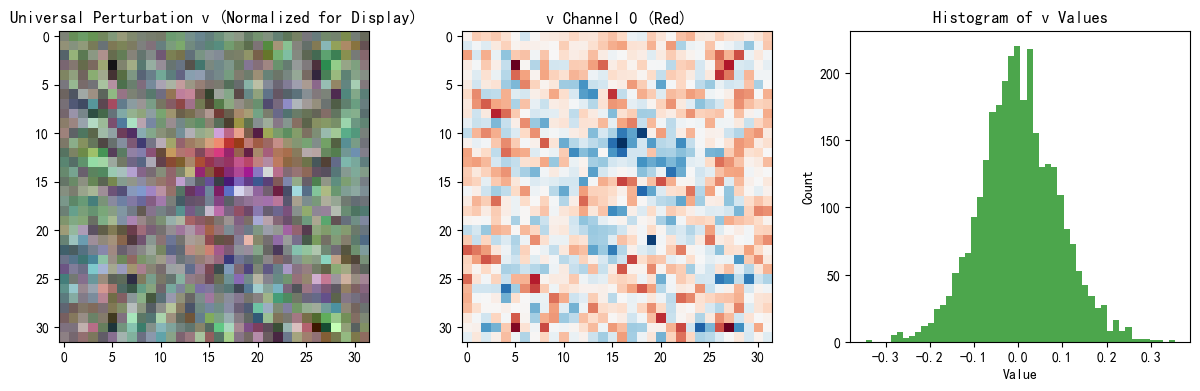

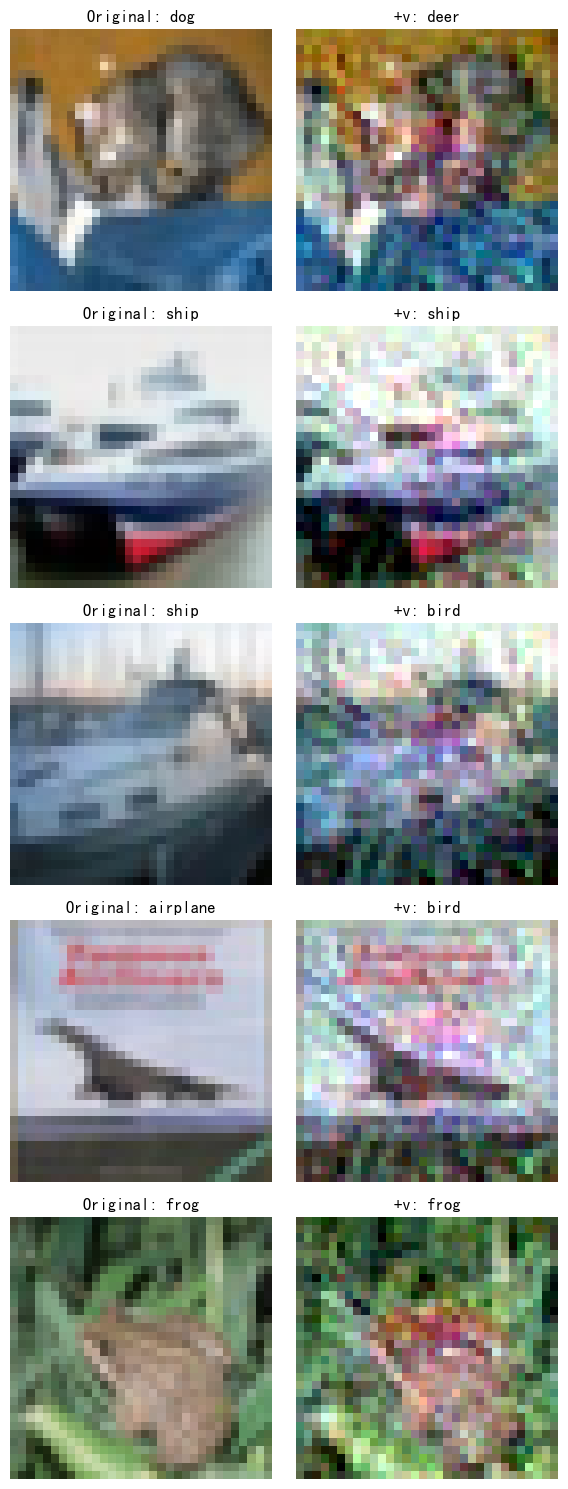

In [8]:
# ==============================
# 可视化：通用扰动本身 + 若干样本加扰动前后的对比
# ==============================
def tensor_to_image(t):
    """将 (C,H,W) 张量转为可显示的 numpy 图像。"""
    return np.clip(t.detach().cpu().numpy().transpose(1, 2, 0), 0, 1)

# 放大通用扰动以便观察
v_np = v.detach().cpu().numpy()
v_display = (v_np - v_np.min()) / (v_np.max() - v_np.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(v_display.transpose(1, 2, 0))
axes[0].set_title("Universal Perturbation v (Normalized for Display)")
axes[1].imshow(v_np[0], cmap='RdBu')
axes[1].set_title("v Channel 0 (Red)")
axes[2].hist(v_np.flatten(), bins=50, color='green', alpha=0.7)
axes[2].set_title("Histogram of v Values")
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Count")
plt.tight_layout()
plt.show()

# 展示多个样本加 v 前后的预测变化
shown = 0
max_show = 5
fig, axes = plt.subplots(max_show, 2, figsize=(6, 3 * max_show))
for idx, (images, labels) in enumerate(test_loader):
    if shown >= max_show:
        break
    images = images.to(device)
    x = images[0:1]
    with torch.no_grad():
        pred_orig = model(x).argmax(dim=1).item()
        x_adv = torch.clamp(x + v, 0, 1)
        pred_adv = model(x_adv).argmax(dim=1).item()

    axes[shown, 0].imshow(tensor_to_image(x.squeeze(0)))
    axes[shown, 0].set_title(f"Original: {classes[pred_orig]}")
    axes[shown, 0].axis('off')
    axes[shown, 1].imshow(tensor_to_image(x_adv.squeeze(0)))
    axes[shown, 1].set_title(f"+v: {classes[pred_adv]}")
    axes[shown, 1].axis('off')
    shown += 1
plt.tight_layout()
plt.show()


## 可视化分析：通用对抗扰动的跨样本攻击效果

UAP 的核心特点是**同一个扰动向量 v** 可以愚弄不同图像。这里先展示增强对比后的扰动本身，再用 2 行子图对比 4 张不同图像在加扰动前后的预测变化。

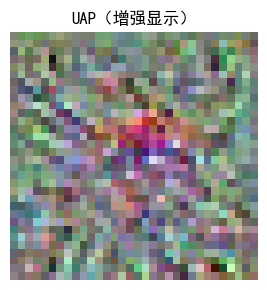

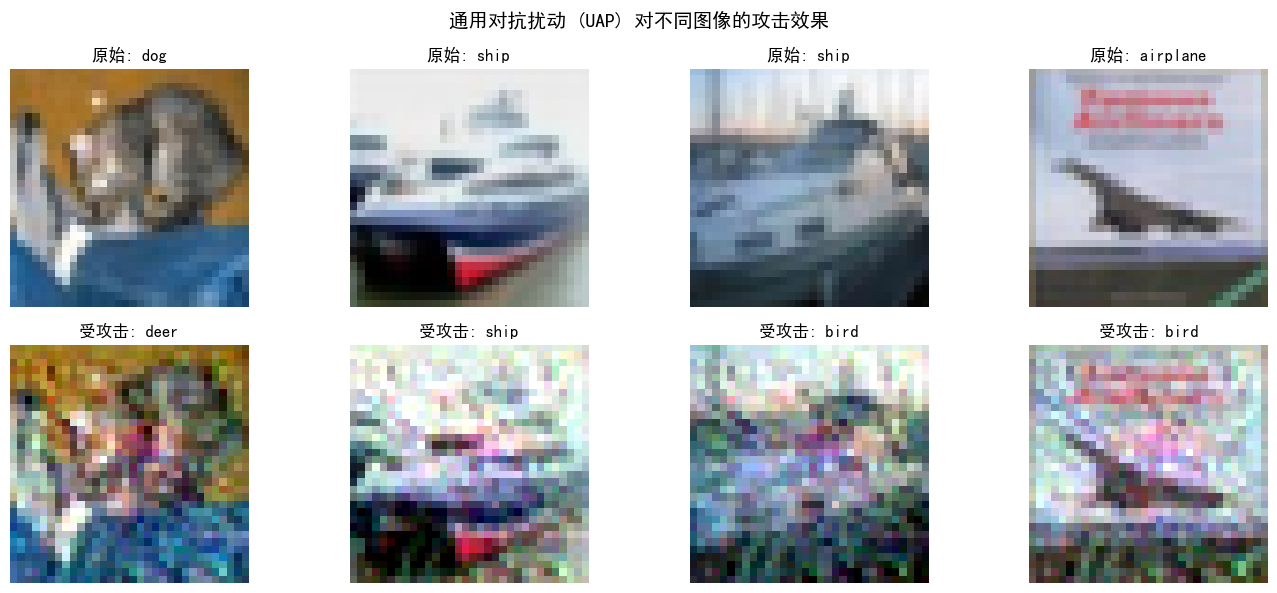

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()

def tensor_to_image(t):
    return np.clip(t.detach().cpu().numpy().transpose(1, 2, 0), 0, 1)

# 从测试集取前 4 张图
samples = []
for imgs, _ in test_loader:
    if len(samples) >= 4:
        break
    samples.append(imgs[0].to(device))

# 1) 增强对比的 UAP 本身
v_np = v.detach().cpu().numpy()
# 将扰动放大 3 倍并归一化到 [0, 1] 以便观察结构
v_amplified = np.clip(v_np * 3.0, -1.0, 1.0)
v_amplified = (v_amplified + 1.0) / 2.0

fig_uap, ax_uap = plt.subplots(figsize=(3, 3))
ax_uap.imshow(tensor_to_image(torch.tensor(v_amplified, dtype=torch.float32, device='cpu')))
ax_uap.set_title('UAP（增强显示）')
ax_uap.axis('off')
plt.tight_layout()
plt.show()

# 2) 2 行子图：上排为 4 张原始图像 + 预测，下排为相同图像 + UAP + 新预测
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
with torch.no_grad():
    for i, x in enumerate(samples):
        x = x.unsqueeze(0)
        pred_orig = model(x).argmax(dim=1).item()
        x_adv = torch.clamp(x + v, 0, 1)
        pred_adv = model(x_adv).argmax(dim=1).item()

        axes[0, i].imshow(tensor_to_image(x.squeeze(0)))
        axes[0, i].set_title(f'原始: {classes[pred_orig]}')
        axes[0, i].axis('off')

        axes[1, i].imshow(tensor_to_image(x_adv.squeeze(0)))
        axes[1, i].set_title(f'受攻击: {classes[pred_adv]}')
        axes[1, i].axis('off')

fig.suptitle('通用对抗扰动 (UAP) 对不同图像的攻击效果', fontsize=14)
plt.tight_layout()
plt.show()


## 实验结论

- **通用对抗扰动存在**：尽管不同图像的内容差异很大，深度学习模型在大量样本上共享相似的决策边界几何结构，因此可以找到一个**单一的扰动向量 $v$** 欺骗大多数样本。
- **泛化能力**：在训练子集上学到的 $v$ 通常也能在测试集上保持较高的 fooling rate，说明 UAP 不只是记住了训练集的特殊性。
- **安全影响**：UAP 是一种 **功能性攻击**——攻击者只需在系统中注入同一份噪声，就能同时影响大量输入，对部署在摄像头、自动驾驶等场景中的模型构成现实威胁。
- 实验绘制的 fooling rate 与 $\\|v\\|_2$ 曲线可以帮助我们理解：增大扰动预算 $\\xi$ 通常会提高欺骗率，但也会使扰动更容易被肉眼察觉。
